In [1]:
# Figure font sizing for journal submission.
# Raise FONT_SCALE (e.g. to 1.4) and re-run to enlarge ALL text uniformly
# across every figure in this notebook. FONT_SCALE = 1.0 reproduces the
# original figures exactly (10.0 is the matplotlib default font.size, and the
# title/tick/legend sizes are relative to it, so they scale automatically).
import matplotlib as mpl

FONT_SCALE = 1.4
mpl.rcParams["font.size"] = 10.0 * FONT_SCALE


# Reproducing and revisiting Axelrod's second tournament

In [2]:
import pathlib
import re

import axelrod as axl
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
import dask.dataframe as dd
import sklearn
from sklearn.feature_selection import RFE, SequentialFeatureSelector, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import json

# Building the appendices

In [3]:
with open("./data/original_tournament/fortran_characteristics.json", "r") as f:
    characteristics = json.load(f)

In [4]:
number_of_translated_strategies = sum(characteristic['axelrod-python_class'] is not None for characteristic in characteristics.values())
with open("../paper/assets/number_of_translated_strategies.tex", "w") as f:
    f.write(str(number_of_translated_strategies))

In [5]:
second_tournament_strategies = [
    name for name in characteristics.keys()
    if characteristics[name]["original_rank"] is not None
]

with open("../paper/assets/list_of_original_tournament_players.tex", "w") as f:
    for name in second_tournament_strategies:
        dictionary = characteristics[name]
        author=dictionary["author"]
        original_rank=dictionary["original_rank"]
        f.write(f"\\item {name} - Original rank: {original_rank}. Authored by {author}\n")

## Helping functions

In [6]:
def get_turns(filename):
    """
    Read the number of turns if included in the file name
    """
    match = re.search("[0-9]+(?=(_turns))", str(filename))
    return int(match.group(0))

def get_repetitions(filename):
    """
    Read the number of repetitions if included in the file name
    """
    match = re.search("[0-9]+(?=(_repetitions))", str(filename))
    return int(match.group(0))

def read_tournament_repetitions(files, player_names=None):
    """
    Read the scores from a collection of gz files 
    representing repetitions of tournaments.
    """
    number_of_opponents = len(player_names) - 1
    dfs = []
    for gz_path in files:
        dfs.append(pd.read_csv(str(gz_path), header=None).iloc[:,0:number_of_opponents + 1])
        
        turns = get_turns(gz_path)
        
        dfs[-1] /= turns * (number_of_opponents)  # Scale all metrics
        dfs[-1].columns = player_names
        
    df = pd.concat(dfs, ignore_index=True)
    return df

In [7]:
original_tournament_data_path = pathlib.Path("./data/original_tournament/")
original_tournament_scores = read_tournament_repetitions(
                                   files=original_tournament_data_path.glob("*scores.gz"), 
                                   player_names=second_tournament_strategies)

original_tournament_scores.head()

,k31r,k32r,k33r,k34r,k35r,k36r,k37r,k38r,k39r,k40r,...,k84r,k85r,k86r,k87r,k88r,k89r,k90r,k91r,k92r,krandomc
0,2.729135,2.823349,2.024322,2.634409,2.790579,1.629544,2.693292,2.688172,2.678955,2.746800,...,2.830261,2.704045,2.748848,2.734255,2.760881,2.206093,2.716334,2.692268,2.869432,1.882744
1,2.727855,2.845366,2.014593,2.619048,2.795187,1.600614,2.691244,2.707117,2.732207,2.749872,...,2.818484,2.726062,2.745008,2.693292,2.796979,2.199949,2.713518,2.716078,2.866359,1.845110
2,2.743472,2.821045,2.035074,2.635177,2.822069,1.594470,2.696877,2.682796,2.747824,2.738863,...,2.833077,2.699693,2.751920,2.683308,2.795443,2.231183,2.718382,2.687660,2.866615,1.771633
3,2.734511,2.821045,2.034818,2.624168,2.815156,1.626472,2.698669,2.703533,2.678187,2.764977,...,2.799283,2.710189,2.752176,2.703789,2.752944,2.198925,2.714030,2.723246,2.873016,1.960317
4,2.742192,2.833077,2.031490,2.630824,2.826421,1.559396,2.692268,2.695084,2.699181,2.709421,...,2.815924,2.708653,2.739887,2.719150,2.762929,2.232207,2.700205,2.726318,2.861495,1.858679


In [8]:
winners = original_tournament_scores.idxmax(axis=1)
proportions = winners.value_counts(normalize=True)
proportions

k92r    0.63064
k42r    0.31488
k75r    0.02244
k60r    0.01024
k82r    0.00824
k32r    0.00800
k44r    0.00384
k78r    0.00156
k35r    0.00016
Name: proportion, dtype: float64

In [9]:
def summarise_scores(scores, get_original=True):
    df = scores.describe(percentiles=[0.05, .25, .5, .75, .95]).transpose()
    df = df.sort_values("mean", ascending=False)  # Sorted on the median
    df.drop('count', axis=1, inplace=True)

    authors = []
    original_ranks = []
    for name in df.index:
        if name in characteristics:
            authors.append(characteristics[name]["author"])
            original_ranks.append(int(characteristics[name]["original_rank"]))
        else:
            authors.append(None)
            original_ranks.append(None)
    df["Author"] = authors
    df["Original rank"] = original_ranks

    return df


original_score_summary = summarise_scores(original_tournament_scores)

original_score_summary.head()

,mean,std,min,5%,25%,50%,75%,95%,max,Author,Original rank
k92r,2.873421,0.008500,2.825513,2.860524,2.866824,2.873553,2.879940,2.886311,2.891234,Anatol Rapoport,1
k42r,2.863492,0.011319,2.807342,2.844913,2.856096,2.864238,2.872015,2.879556,2.892752,Otto Borufsen,3
k75r,2.832695,0.024357,2.720779,2.787652,2.817972,2.835777,2.849974,2.867384,2.901131,Paul D Harrington,8
k49r,2.825359,0.014380,2.751833,2.798594,2.817239,2.827029,2.835505,2.845622,2.866359,Rob Cave,4
k60r,2.820809,0.029735,2.703289,2.771208,2.800150,2.820872,2.845832,2.864055,2.890169,Jim Graaskamp and Ken Katzen,6


Let us consider the ranks over all repetitions of the tournaments (we have a lot of tournaments).

In [10]:
def violon_plot(scores, summary, filename):
    number_of_players = len(scores.columns)
    fig, ax = plt.subplots() 
    width = number_of_players / 3
    height = width / (1.5 * 1.414)
    spacing = 4 
    positions = spacing * np.arange(1, number_of_players + 1, 1)
    fig.set_size_inches(width, height) 
    
    summary.sort_values("Original rank", inplace=True)

    ax.violinplot([scores[player] for player in summary.index],
                  positions=positions, widths=spacing / 2,
                  showmedians=True, showextrema=False)
    ax.set_xticks(positions) 
    ax.set_xlabel("Strategy file name, ordered by original rank", fontsize=20 * FONT_SCALE)
    ax.set_xticklabels(summary.index, rotation=90)
    ax.set_xlim([0, spacing * (number_of_players + 1)])
    ax.tick_params(axis='x', which='both', labelsize=20 * FONT_SCALE)
    ax.tick_params(axis='y', which='both', labelsize=40 * FONT_SCALE)
    
    
    fig.tight_layout()
    fig.savefig(filename, transparent=True);

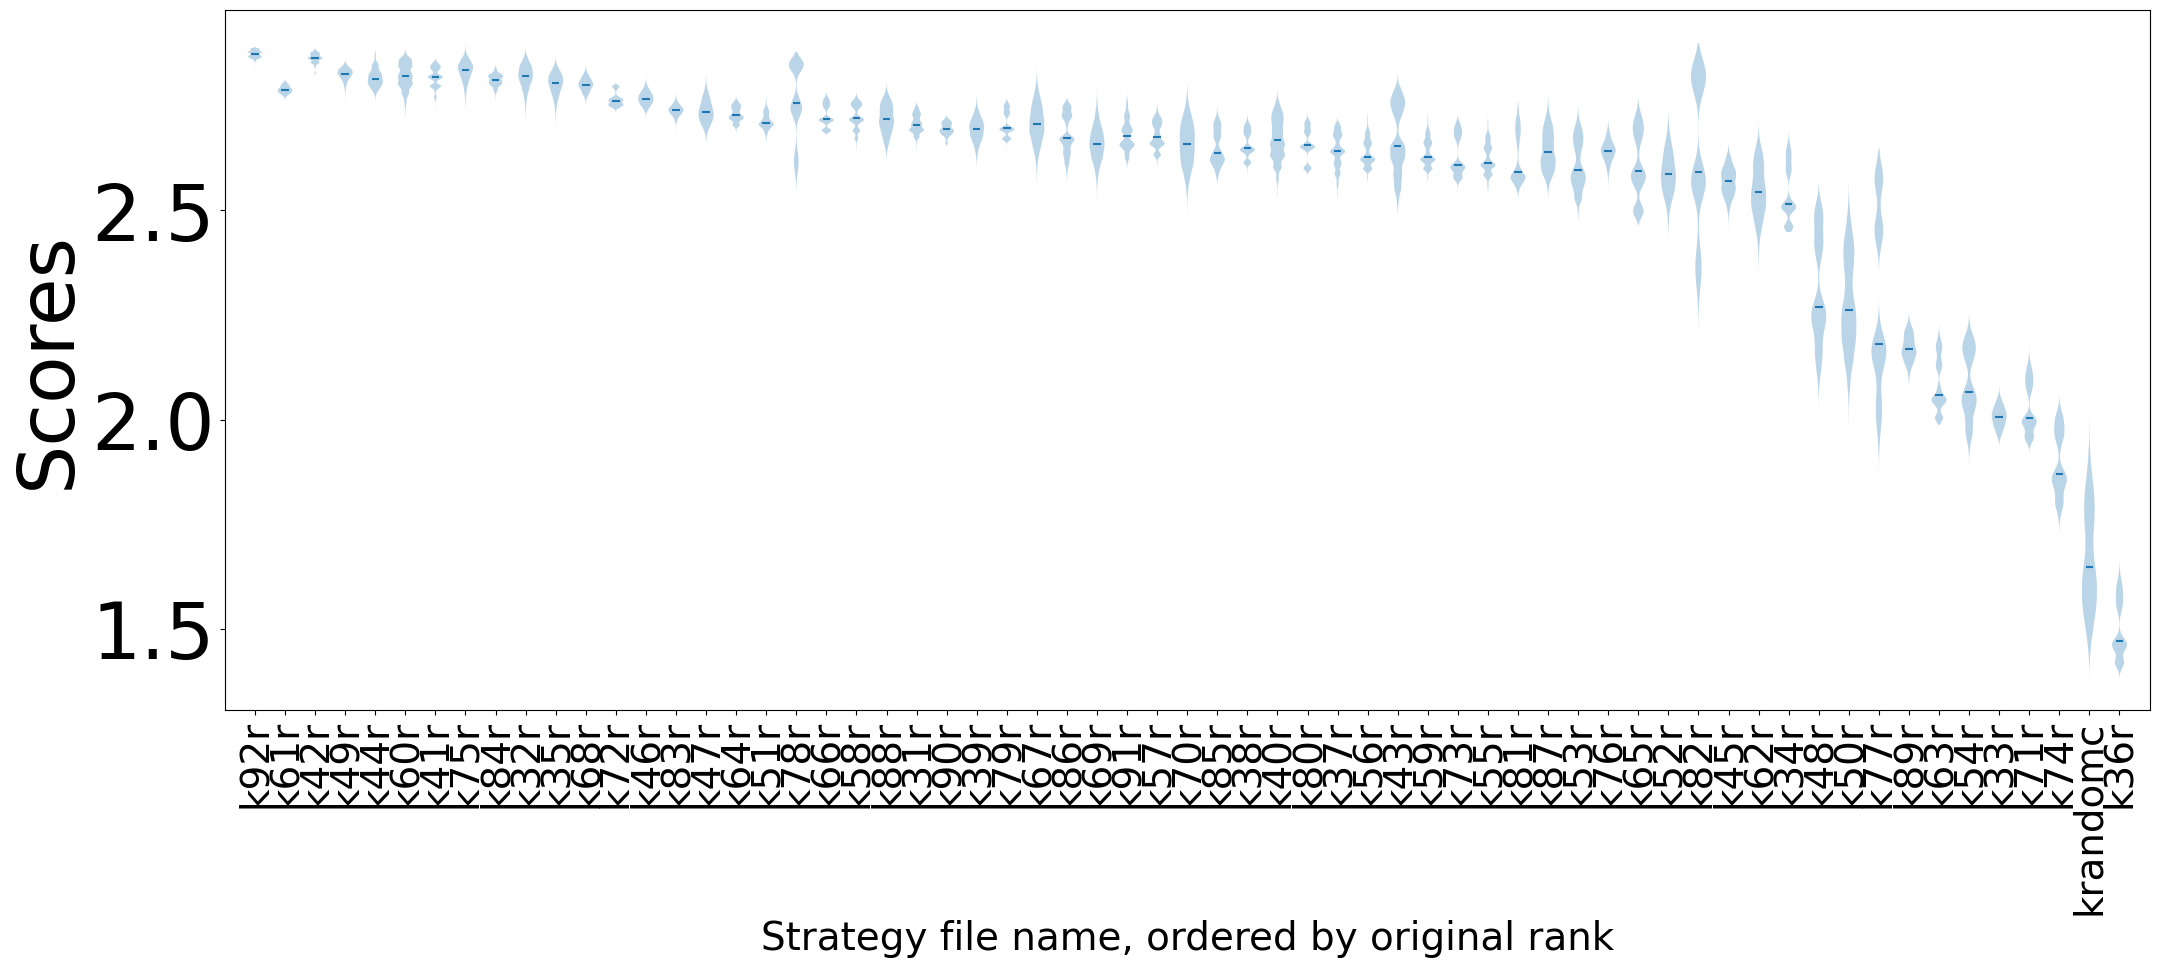

In [11]:
violon_plot(original_tournament_scores, original_score_summary, "../paper/assets/original_scores_boxplots.pdf")
plt.ylabel("Scores", fontsize=40 * FONT_SCALE);

In [12]:
def summarise_ranks(scores):
    df = scores.rank(axis=1, ascending=False).describe(percentiles=[0.05, .25, .5, .75, .95]).transpose()
    df = df.sort_values("mean")
    for var in ["min", "max"]:
        df[var] = df[var].astype(int)
    df.drop('count', axis=1, inplace=True)

    authors = []
    original_ranks = []
    for name in df.index:
        if name in characteristics:
            authors.append(characteristics[name]["author"])
            original_ranks.append(int(characteristics[name]["original_rank"]))
        else:
            authors.append(None)
            original_ranks.append(None)
    df["Author"] = authors
    df["Original rank"] = original_ranks
    
    return df

original_rank_summary = summarise_ranks(original_tournament_scores)

original_rank_summary.head(15)

,mean,std,min,5%,25%,50%,75%,95%,max,Author,Original rank
k92r,1.50168,0.780744,1,1.0,1.0,1.0,2.0,3.0,8,Anatol Rapoport,1
k42r,1.85866,0.744174,1,1.0,1.0,2.0,2.0,3.0,7,Otto Borufsen,3
k75r,5.40924,2.729821,1,2.0,3.0,5.0,7.0,11.0,17,Paul D Harrington,8
k49r,6.41728,2.477084,2,3.0,4.0,6.0,8.0,11.0,16,Rob Cave,4
k60r,6.95680,3.219902,1,3.0,4.0,6.0,9.0,13.0,19,Jim Graaskamp and Ken Katzen,6
k32r,7.35866,3.410193,1,3.0,4.0,7.0,10.0,13.0,25,Charles Kluepfel,10
k41r,7.37350,2.408697,2,4.0,6.0,7.0,9.0,12.0,16,Herb Weiner,7
k44r,7.85574,3.863102,1,3.0,4.0,8.0,11.0,14.0,18,William Adams,5
k84r,8.54712,2.203981,2,5.0,7.0,9.0,10.0,12.0,18,T Nicolaus Tideman and Paula Chieruzz,9
k35r,9.71078,3.302662,1,4.0,7.0,10.0,12.0,15.0,29,Abraham Getzler,11


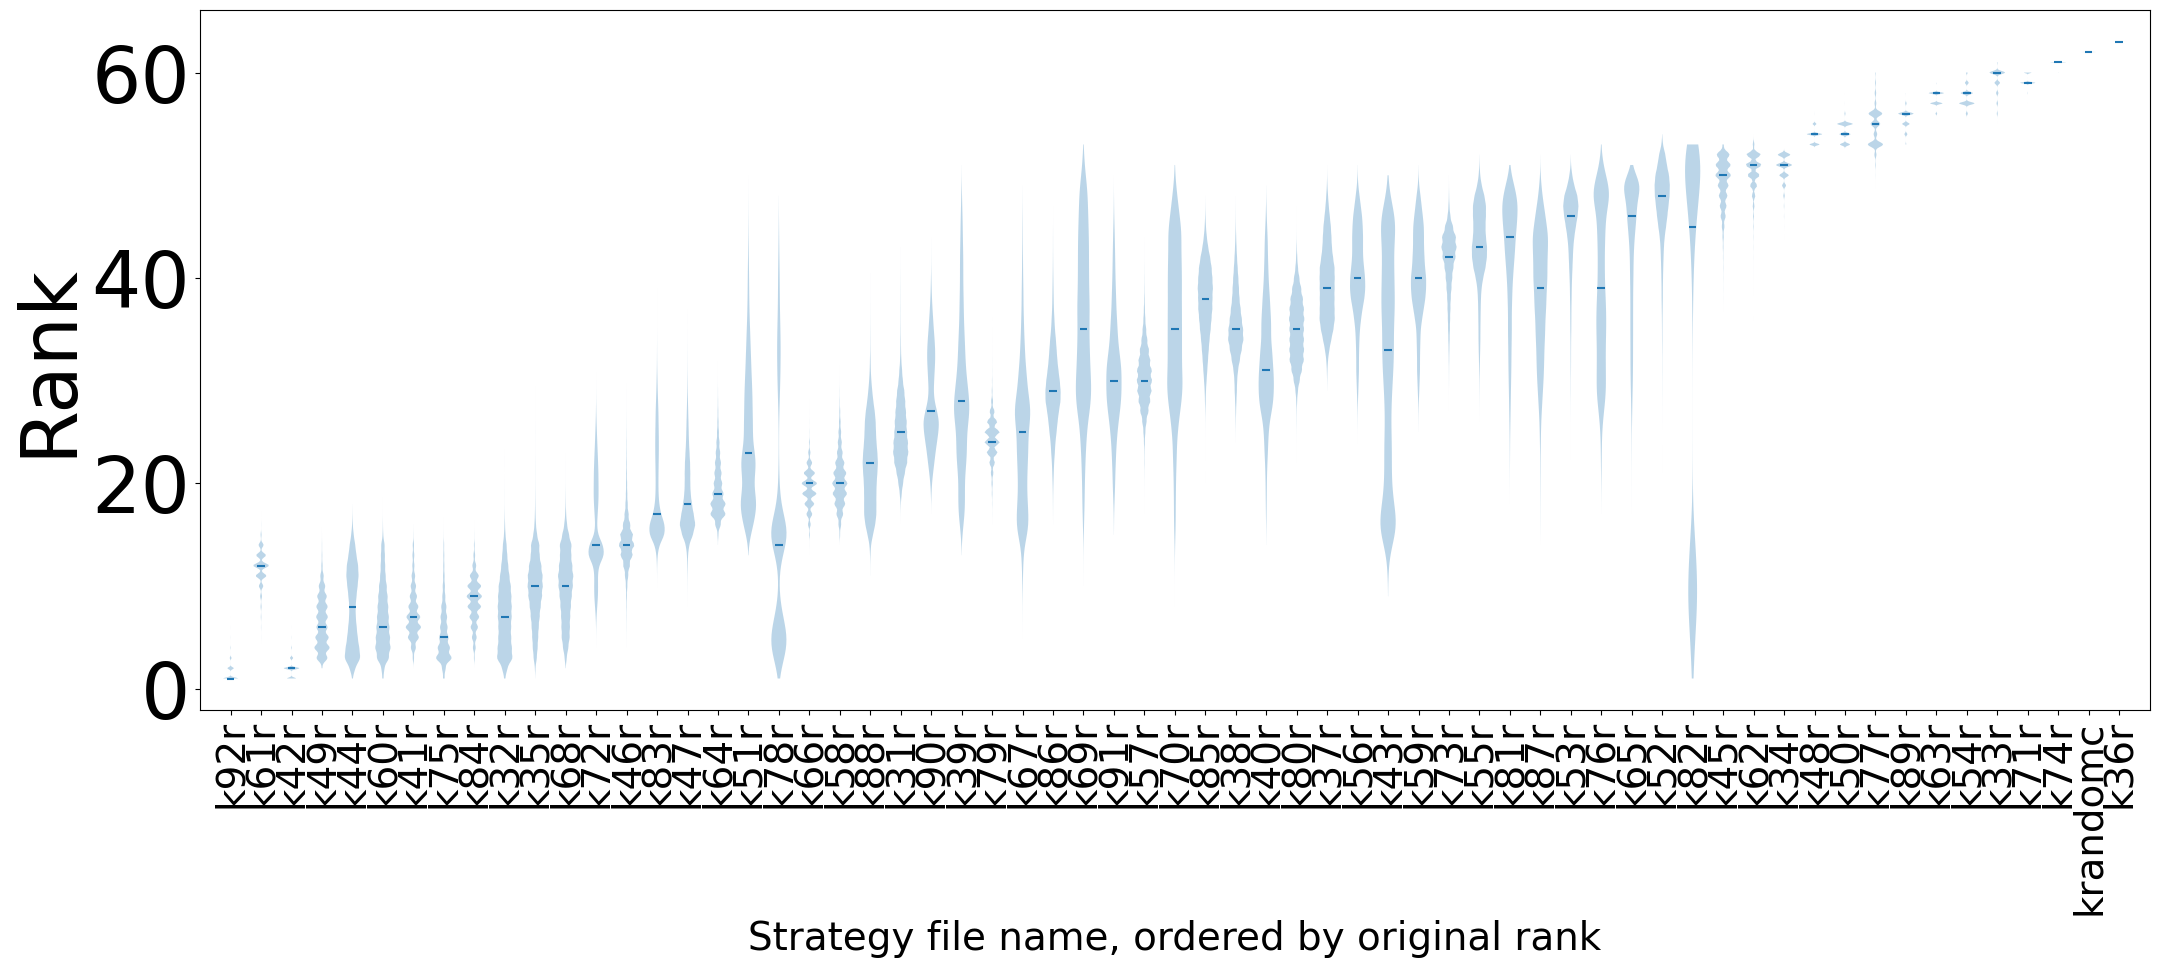

In [13]:
violon_plot(original_tournament_scores.rank(axis=1, ascending=False), 
            original_rank_summary, "../paper/assets/original_ranks_boxplots.pdf")
plt.ylabel("Rank", fontsize=40 * FONT_SCALE);

In [14]:
def read_payoff_matrix(files):
    arrays = []
    turns = []
    repetitions = 0
    for gz_path in files:
        repetitions += get_repetitions(gz_path)
        arrays.append(np.array(pd.read_csv(str(gz_path), header=None)))  # Read through pd to deal with float conversion
        turns.append(get_turns(str(gz_path)))
    payoff_matrix = sum(array * turn for turn, array in zip(turns, arrays)) / sum(turns)

    return payoff_matrix, repetitions

In [15]:
original_tournament_payoff_matrix, original_repetitions = read_payoff_matrix(original_tournament_data_path.glob("*payoff_matrix.gz"))

In [16]:
scores = pd.DataFrame(original_tournament_payoff_matrix, 
                      second_tournament_strategies)
scores.columns = scores.index
scores

,k31r,k32r,k33r,k34r,k35r,k36r,k37r,k38r,k39r,k40r,...,k84r,k85r,k86r,k87r,k88r,k89r,k90r,k91r,k92r,krandomc
k31r,3.000000,3.000000,1.825166,3.000000,3.000000,1.355929,3.000000,3.000000,1.605298,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,1.704636,3.000000,3.000000,3.000000,2.202516
k32r,3.000000,3.000000,2.266114,3.000000,3.000000,1.239309,3.000000,3.000000,2.955243,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,2.587502,3.000000,3.000000,3.000000,2.802069
k33r,1.315232,1.273490,2.867550,0.986755,2.723067,1.262991,0.986755,1.315232,1.258278,1.204787,...,1.468874,1.316556,1.006623,1.840296,2.059480,1.613245,3.891391,2.058278,2.900662,2.765306
k34r,3.000000,3.000000,1.284768,3.000000,3.000000,1.357888,3.000000,3.000000,1.403974,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,1.841060,3.000000,3.000000,3.000000,2.979328
k35r,3.000000,3.000000,2.712783,3.000000,3.000000,1.252144,3.000000,3.000000,2.945975,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,2.546348,3.000000,3.000000,3.000000,2.240069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
k89r,2.539073,2.659256,1.904636,0.980132,2.560372,1.150798,1.033113,1.033113,3.125828,1.113841,...,2.033113,1.691391,1.491391,1.749894,2.352756,2.613245,3.152318,3.492715,2.649007,2.432150
k90r,3.000000,3.000000,1.580132,3.000000,3.000000,1.162890,3.000000,3.000000,1.605298,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,2.490066,3.000000,3.000000,3.000000,1.871283
k91r,3.000000,3.000000,1.488742,3.000000,3.000000,1.211602,3.000000,3.000000,2.084768,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,1.426490,3.000000,3.000000,3.000000,2.553775
k92r,3.000000,3.000000,2.900662,3.000000,3.000000,1.257422,3.000000,3.000000,2.993377,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,2.635762,3.000000,3.000000,3.000000,2.247304


In [17]:
scores["Scores"] = np.mean(original_tournament_payoff_matrix, axis=1)
scores["Reproduced Rank"] = scores["Scores"].rank(ascending=False).astype(int)
scores["Original Rank"] =  [characteristics[name]["original_rank"] for name in scores.index]
scores["Author"] =  [characteristics[name]["author"] for name in scores.index]
scores.sort_values("Original Rank", inplace=True)

In [18]:
scores[scores.index == 'k69r']

,k31r,k32r,k33r,k34r,k35r,k36r,k37r,k38r,k39r,k40r,...,k88r,k89r,k90r,k91r,k92r,krandomc,Scores,Reproduced Rank,Original Rank,Author
k69r,3.166317,2.767996,1.50259,1.10279,2.591074,1.254612,2.863437,3.166418,2.969217,1.353466,...,2.450786,2.641048,3.164881,3.035947,2.974094,2.93037,2.656304,31,29,Johann Joss


In [19]:
scores.head()

,k31r,k32r,k33r,k34r,k35r,k36r,k37r,k38r,k39r,k40r,...,k88r,k89r,k90r,k91r,k92r,krandomc,Scores,Reproduced Rank,Original Rank,Author
k92r,3.0,3.0,2.900662,3.0,3.0,1.257422,3.0,3.0,2.993377,3.0,...,3.0,2.635762,3.0,3.0,3.0,2.247304,2.878471,1,1,Anatol Rapoport
k61r,3.0,3.0,2.854305,3.0,3.0,1.112628,3.0,3.0,2.993377,3.0,...,3.0,2.530366,3.0,3.0,3.0,1.875764,2.790747,12,2,Danny C Champion
k42r,3.0,3.0,2.137748,3.0,3.0,1.199216,3.0,3.0,2.993377,3.0,...,3.0,2.621192,3.0,3.0,3.0,2.798713,2.860687,2,3,Otto Borufsen
k49r,3.0,3.0,2.279602,3.0,3.0,1.286362,3.0,3.0,2.904710,3.0,...,3.0,2.364432,3.0,3.0,3.0,2.694843,2.825954,4,4,Rob Cave
k44r,3.0,3.0,2.360991,3.0,3.0,1.227057,3.0,3.0,2.791589,3.0,...,3.0,2.446443,3.0,3.0,3.0,2.204224,2.825962,3,5,William Adams


In [20]:
scores.index

Index(['k92r', 'k61r', 'k42r', 'k49r', 'k44r', 'k60r', 'k41r', 'k75r', 'k84r',
       'k32r', 'k35r', 'k68r', 'k72r', 'k46r', 'k83r', 'k47r', 'k64r', 'k51r',
       'k78r', 'k66r', 'k58r', 'k88r', 'k31r', 'k90r', 'k39r', 'k79r', 'k67r',
       'k86r', 'k69r', 'k91r', 'k57r', 'k70r', 'k85r', 'k38r', 'k40r', 'k80r',
       'k37r', 'k56r', 'k43r', 'k59r', 'k73r', 'k55r', 'k81r', 'k87r', 'k53r',
       'k76r', 'k65r', 'k52r', 'k82r', 'k45r', 'k62r', 'k34r', 'k48r', 'k50r',
       'k77r', 'k89r', 'k63r', 'k54r', 'k33r', 'k71r', 'k74r', 'krandomc',
       'k36r'],
      dtype='object')

There are a few other variants of the tournament:

- An alternative `k47` (two were in the original source code)
- A python implementation of the strategy by Champion (this seems to be the strategy with the biggest performance discrepancy)
- Using all python implementations of the original tournament

In [21]:
original_tournament_with_alt_k74r_data_path = pathlib.Path("./data/original_with_alt_k74r_tournament/")
original_tournament_with_alt_k74r_payoff_matrix, _ = read_payoff_matrix(original_tournament_with_alt_k74r_data_path.glob("*payoff_matrix.gz"))
original_tournament_with_alt_k74r_index = pd.read_csv(
    "./data/original_with_alt_k74r_tournament/players.index",
    names=("Name",),
)

In [22]:
alt_k74r_scores = pd.DataFrame(original_tournament_with_alt_k74r_payoff_matrix, 
                      original_tournament_with_alt_k74r_index["Name"])
alt_k74r_scores.columns = alt_k74r_scores.index
alt_k74r_scores["Scores"] = np.mean(original_tournament_with_alt_k74r_payoff_matrix, axis=1)
alt_k74r_scores["Reproduced Rank"] = alt_k74r_scores["Scores"].rank(ascending=False).astype(int)
alt_k74r_scores["Original Rank"] =  [characteristics[name]["original_rank"] for name in alt_k74r_scores.index]
alt_k74r_scores["Author"] =  [characteristics[name]["author"] for name in alt_k74r_scores.index]
alt_k74r_scores.sort_values("Original Rank", inplace=True)
alt_k74r_scores

Name,k31r,k32r,k33r,k34r,k35r,k36r,k37r,k38r,k39r,k40r,...,k88r,k89r,k90r,k91r,k92r,krandomc,Scores,Reproduced Rank,Original Rank,Author
Name,,,,,,,,,,,,,,,,,,,,,
k92r,3.000000,3.000000,2.900662,3.000000,3.000000,1.257422,3.000000,3.000000,2.993377,3.000000,...,3.000000,2.635762,3.000000,3.000000,3.000000,2.247304,2.854714,1,1.0,Anatol Rapoport
k61r,3.000000,3.000000,2.854305,3.000000,3.000000,1.112628,3.000000,3.000000,2.993377,3.000000,...,3.000000,2.530366,3.000000,3.000000,3.000000,1.875764,2.779994,12,2.0,Danny C Champion
k42r,3.000000,3.000000,2.137748,3.000000,3.000000,1.199216,3.000000,3.000000,2.993377,3.000000,...,3.000000,2.621192,3.000000,3.000000,3.000000,2.798713,2.841513,3,3.0,Otto Borufsen
k49r,3.000000,3.000000,2.279602,3.000000,3.000000,1.286362,3.000000,3.000000,2.904710,3.000000,...,3.000000,2.364432,3.000000,3.000000,3.000000,2.694843,2.843891,2,4.0,Rob Cave
k44r,3.000000,3.000000,2.360991,3.000000,3.000000,1.227057,3.000000,3.000000,2.791589,3.000000,...,3.000000,2.446443,3.000000,3.000000,3.000000,2.204224,2.820540,4,5.0,William Adams
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
k33r,1.315232,1.273490,2.867550,0.986755,2.723067,1.262991,0.986755,1.315232,1.258278,1.204787,...,2.059480,1.613245,3.891391,2.058278,2.900662,2.765306,2.061609,58,59.0,Harold Rabbie
k71r,3.996026,1.095208,3.830464,1.033113,1.104713,1.300448,1.033113,3.996026,3.825166,1.064943,...,1.343227,2.770861,3.996026,2.773510,1.059603,2.609430,1.962099,60,60.0,James E Hall
krandomc,2.360713,0.960745,1.050703,0.547155,2.270139,0.821423,0.567035,0.829025,1.423339,1.148856,...,2.348461,1.822680,3.136656,1.547000,2.263748,2.248527,1.623870,61,62.0,None


In [23]:
fortran_strategies = [s for s in second_tournament_strategies 
                      if characteristics[s]["axelrod-python_class"] is None]
assert len(fortran_strategies) == 38, f"Number of Fortran strategies={len(fortran_strategies)}"

In [24]:
fortran_strategies = [s for s in second_tournament_strategies 
                      if characteristics[s]["axelrod-python_class"] is None]
python_strategies = [s for s in second_tournament_strategies 
                     if characteristics[s]["axelrod-python_class"] is not None]

original_tournament_with_all_py_data_path = pathlib.Path("./data/original_tournament_with_python_implementations/")
original_tournament_with_all_py_payoff_matrix, _ = read_payoff_matrix(original_tournament_with_all_py_data_path .glob("*payoff_matrix.gz"))

In [25]:
player_names = fortran_strategies + python_strategies
py_scores = pd.DataFrame(original_tournament_with_all_py_payoff_matrix, 
                         player_names, 
                         columns=player_names)
py_scores["Scores"] = np.mean(original_tournament_with_all_py_payoff_matrix, axis=1)
py_scores["Reproduced Rank"] = py_scores["Scores"].rank(ascending=False).astype(int)
py_scores["Original Rank"] =  [characteristics[name]["original_rank"] for name in py_scores.index]
py_scores["Author"] =  [characteristics[name]["author"] for name in py_scores.index]
py_scores.sort_values("Original Rank", inplace=True)
py_scores

,k33r,k36r,k37r,k38r,k39r,k40r,k43r,k45r,k46r,k48r,...,k83r,k84r,k86r,k90r,k92r,krandomc,Scores,Reproduced Rank,Original Rank,Author
k92r,2.900662,1.259403,3.000000,3.000000,2.993377,3.000000,2.993377,2.993377,3.000000,2.993377,...,3.000000,3.000000,3.000000,3.000000,3.000000,2.242220,2.878475,1,1,Anatol Rapoport
k61r,2.854305,1.113094,3.000000,3.000000,2.993377,3.000000,2.993377,2.645033,3.000000,2.960265,...,3.000000,3.000000,3.000000,3.000000,3.000000,1.878004,2.790764,12,2,Danny C Champion
k42r,2.137748,1.200790,3.000000,3.000000,2.993377,3.000000,2.993377,2.993377,3.000000,2.993377,...,3.000000,3.000000,3.000000,3.000000,3.000000,2.794450,2.860572,2,3,Otto Borufsen
k49r,2.282295,1.283781,3.000000,3.000000,2.907379,3.000000,2.930002,2.883492,3.000000,2.730545,...,3.000000,3.000000,3.000000,3.000000,3.000000,2.698585,2.824885,5,4,Rob Cave
k44r,2.361863,1.203733,3.000000,3.000000,2.791834,3.000000,2.890177,2.427991,3.000000,2.091951,...,3.000000,3.000000,3.000000,3.000000,3.000000,2.201888,2.826362,3,5,William Adams
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
k33r,2.867550,1.263450,0.986755,1.315232,1.258278,1.204446,1.083444,3.389404,3.147394,1.189404,...,3.107588,1.468874,1.006623,3.891391,2.900662,2.762901,2.015003,59,59,Harold Rabbie
k71r,3.830464,1.300995,1.033113,3.996026,3.825166,1.065122,1.238411,1.278146,2.346320,1.772185,...,2.073489,2.153642,1.059603,3.996026,1.059603,2.611283,1.983032,60,60,James E Hall
k74r,1.304636,1.356153,1.019868,1.099338,1.585430,1.060760,1.218543,2.490066,3.126184,1.292715,...,2.056699,1.656954,1.059603,3.390728,2.509934,2.960549,1.843530,61,61,Edward Friedland
krandomc,1.055618,0.820377,0.567085,0.826649,1.423580,1.147213,0.791913,2.622208,3.100197,1.627337,...,3.118427,0.638291,0.978309,3.135394,2.258889,2.251642,1.619768,62,62,None


In [26]:
original_tournament_with_py_ch_data_path = pathlib.Path("./data/original_tournament_with_python_champion/")
original_tournament_with_py_ch_payoff_matrix, _ = read_payoff_matrix(original_tournament_with_py_ch_data_path.glob("*payoff_matrix.gz"))
original_tournament_with_py_ch_index = pd.read_csv(
    "./data/original_tournament_with_python_champion/players.index",
    names=("Name",),
)

In [27]:
py_ch_scores = pd.DataFrame(original_tournament_with_py_ch_payoff_matrix, 
                      original_tournament_with_py_ch_index["Name"])
py_ch_scores.columns = py_ch_scores.index
py_ch_scores["Scores"] = np.mean(original_tournament_with_py_ch_payoff_matrix, axis=1)
py_ch_scores["Reproduced Rank"] = py_ch_scores["Scores"].rank(ascending=False).astype(int)
original_names = list(py_ch_scores.index)[:-1] + ["k61r"]
py_ch_scores["Original Rank"] =  [characteristics[name]["original_rank"] for name in original_names]
py_ch_scores["Author"] =  [characteristics[name]["author"] for name in original_names]
py_ch_scores.sort_values("Original Rank", inplace=True)
py_ch_scores

Name,k31r,k32r,k33r,k34r,k35r,k36r,k37r,k38r,k39r,k40r,...,k89r,k90r,k91r,k92r,krandomc,Second by Champion,Scores,Reproduced Rank,Original Rank,Author
Name,,,,,,,,,,,,,,,,,,,,,
k92r,3.000000,3.000000,2.900662,3.000000,3.000000,1.258877,3.000000,3.000000,2.993377,3.000000,...,2.635762,3.000000,3.000000,3.000000,2.245900,3.000000,2.878608,1,1,Anatol Rapoport
Second by Champion,3.000000,3.000000,2.854305,3.000000,3.000000,1.122485,3.000000,3.000000,2.993377,3.000000,...,2.529996,3.000000,3.000000,3.000000,1.885074,3.000000,2.790977,12,2,Danny C Champion
k42r,3.000000,3.000000,2.137748,3.000000,3.000000,1.199216,3.000000,3.000000,2.993377,3.000000,...,2.621192,3.000000,3.000000,3.000000,2.795226,3.000000,2.860548,2,3,Otto Borufsen
k49r,3.000000,3.000000,2.279602,3.000000,3.000000,1.286362,3.000000,3.000000,2.904710,3.000000,...,2.367934,3.000000,3.000000,3.000000,2.695899,3.000000,2.826069,4,4,Rob Cave
k44r,3.000000,3.000000,2.360991,3.000000,3.000000,1.227057,3.000000,3.000000,2.791589,3.000000,...,2.446346,3.000000,3.000000,3.000000,2.202711,3.000000,2.825859,5,5,William Adams
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
k33r,1.315232,1.273490,2.867550,0.986755,2.723067,1.262991,0.986755,1.315232,1.258278,1.204787,...,1.613245,3.891391,2.058278,2.900662,2.764630,2.986755,2.015043,59,59,Harold Rabbie
k71r,3.996026,1.094913,3.830464,1.033113,1.105651,1.301249,1.033113,3.996026,3.825166,1.065183,...,2.770861,3.996026,2.773510,1.059603,2.614248,2.095265,1.981918,60,60,James E Hall
k74r,2.509934,1.757329,1.304636,1.019868,1.566409,1.357748,1.019868,1.099338,1.585430,1.060741,...,2.165563,3.390728,1.262252,2.509934,2.957493,3.116932,1.842955,61,61,Edward Friedland


k61r k76r


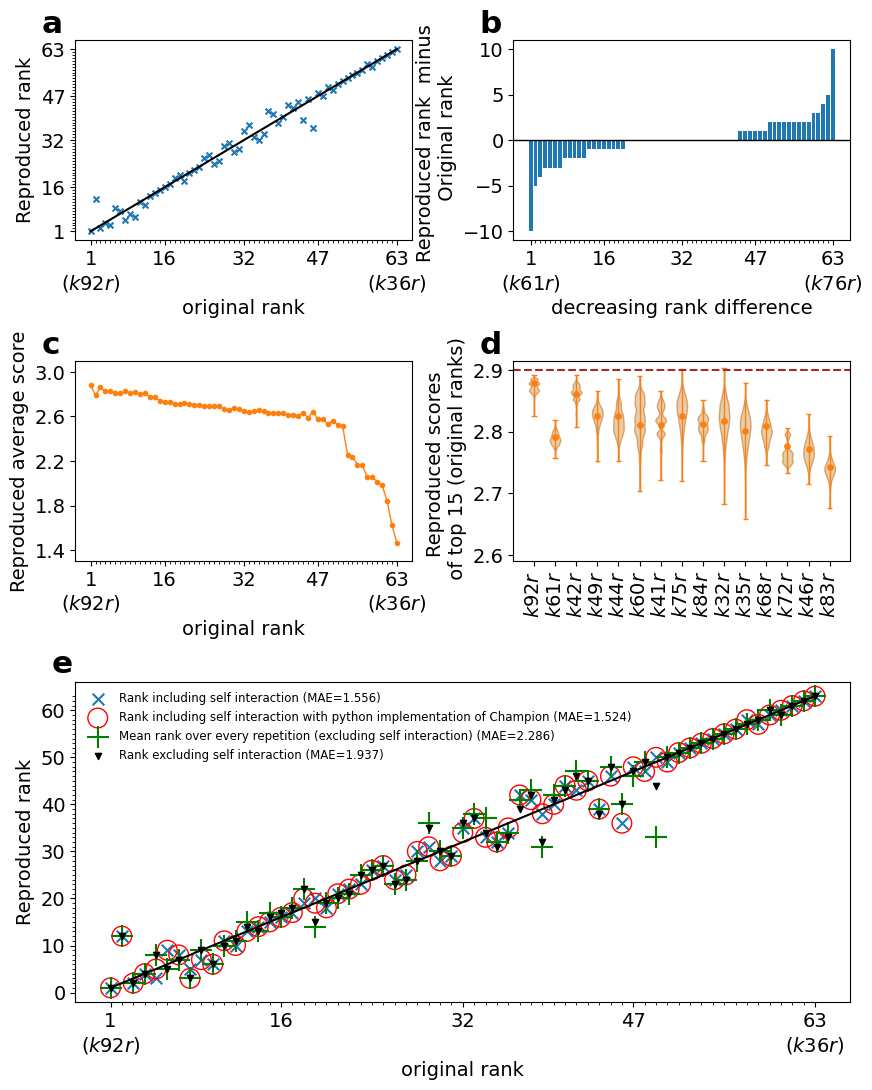

In [58]:
fig, axes = plt.subplot_mosaic("""AB
                                  CD
                                  EE""", figsize=(10, 12.5),
                               gridspec_kw={"hspace": 0.5, "wspace": 0.3,
                                            "height_ratios": [1, 1, 1.6]});

xtick_positions = range(1, len(scores.index) + 1)
labels = [f"{i}" for i in [1, 16, 32, 47, 63]]
labels[0] = "1\n" + r"$(\mathit{k92r})$"
labels[-1] = "63\n" + r"$(\mathit{k36r})$"


for letter in "ABCE":
    axes[letter].set_xticks([1, 16, 32, 47, 63])
    axes[letter].set_xticks(range(1, len(scores.index) + 1), minor=True)

for letter in "ACE":
    axes[letter].set_xlabel("original rank")
    axes[letter].set_xticklabels(labels)

# Panel A: Original Rank against Reproduced Rank
axes["A"].plot(scores["Original Rank"], scores["Original Rank"], color="black")

axes["A"].scatter(
    scores["Original Rank"], scores["Reproduced Rank"],
    label="Reproduced Rank", s=18, marker='x', color='tab:blue'
)

# Panel B: Rank difference
orig_col = "Reproduced Rank"
repr_col = "Original Rank"

diff = (scores[repr_col] - scores[orig_col]).rename("diff")
diff_sorted = diff.sort_values()
labels_sorted = diff_sorted.index.to_list()

axes["B"].bar(xtick_positions, diff_sorted.values)

max_abs = float(max(diff_sorted.max(), -diff_sorted.min()))
axes["B"].set_ylim(-1.1 * max_abs, 1.1 * max_abs)
axes["B"].axhline(0, linewidth=1, linestyle="-", color="black")

labels = [f"{i}" for i in [1, 16, 32, 47, 63]]
labels[0] = labels_sorted[0]
labels[-1] = labels_sorted[-1]
print(labels[0], labels[-1])

labels[0] = "1\n" + r"$(\mathit{k61r})$"
labels[-1] = "63\n" + r"$(\mathit{k76r})$"

axes["B"].set_xticklabels(labels)

axes["B"].set_xlabel("decreasing rank difference");

# Panel C: Mean score
axes["C"].plot(xtick_positions, scores["Scores"].values, '-o', markersize=3, color='tab:orange', linewidth=1)

# Panel D: Score of top 15
data = [original_tournament_scores[col] for col in scores.index]
violin_parts = axes["D"].violinplot(data[:15])

axes["D"].scatter(xtick_positions[:15], scores["Scores"].values[:15], s=15, color='tab:orange')
axes["D"].set_xticks(xtick_positions[:15])
axes["D"].set_xticklabels([r"$\mathit{" + i + "}$" for i in scores.index[:15]], rotation=90)


for pc in violin_parts['bodies']:
        pc.set_facecolor('burlywood')
        pc.set_edgecolor('peru')
        pc.set_alpha(0.7)      

for partname in ('cbars','cmins','cmaxes'):
    vp = violin_parts[partname]
    vp.set_edgecolor('tab:orange')
    vp.set_linewidth(1)


# Panel E: Reproducing different methods

self_interaction_mean_abs_error = mean_absolute_error(scores["Original Rank"], 
                                                      scores["Reproduced Rank"])
self_interaction_py_ch_mean_abs_error = mean_absolute_error(scores["Original Rank"], 
                                                            py_ch_scores["Reproduced Rank"])
self_interaction_py_all_mean_abs_error = mean_absolute_error(scores["Original Rank"], 
                                                              py_scores["Reproduced Rank"])
excl_self_interaction_mean_abs_error = mean_absolute_error(scores["Original Rank"], 
                                                           original_score_summary["mean"].rank(ascending=False))
mean_rank_mean_abs_error = mean_absolute_error(scores["Original Rank"],
                                               original_rank_summary["mean"].rank(ascending=True))


axes["E"].plot(scores["Original Rank"], scores["Original Rank"], color="black")
axes["E"].scatter(scores["Original Rank"], scores["Reproduced Rank"], 
            label="Rank including self interaction (MAE={:.3f})".format(self_interaction_mean_abs_error),
            s=70,
            marker="x",
            color="tab:blue")
axes["E"].scatter(py_ch_scores["Original Rank"], py_ch_scores["Reproduced Rank"], 
            label="Rank including self interaction with python implementation of Champion (MAE={:.3f})".format(self_interaction_py_ch_mean_abs_error),
            s=200,
            facecolors='none', edgecolors='r')
# axes["E"].scatter(py_scores["Original Rank"], py_scores["Reproduced Rank"], 
#             label="Rank including self interaction with python implementation of all strategies (MAE={:.3f})".format(self_interaction_py_all_mean_abs_error),
#             s=50,
#             facecolors='r',
#             marker="D")
axes["E"].scatter(scores["Original Rank"], original_rank_summary["mean"].rank(ascending=True), 
            label="Mean rank over every repetition (excluding self interaction) (MAE={:.3f})".format(mean_rank_mean_abs_error),
            s=250,
            facecolors='g',
            marker="+")
axes["E"].scatter(scores["Original Rank"], 
            original_score_summary["mean"].rank(ascending=False), 
            label="Rank excluding self interaction (MAE={:.3f})".format(excl_self_interaction_mean_abs_error), 
            s=20,
            marker="v", color='black')


axes["E"].set_ylabel("Reproduced rank")

axes["E"].legend(frameon=False, fontsize=8.5, loc=2)

# Labeling and Stuff
axes["A"].set_yticks([1, 16, 32, 47, 63])
axes["A"].set_yticks(range(1, len(scores.index) + 1), minor=True)
axes["A"].set_ylabel("Reproduced rank")
axes["B"].set_ylabel("Reproduced rank  minus \n Original rank")

axes["C"].set_yticks(np.linspace(1.4, 3, 5))
axes["C"].set_ylim(1.3, 3.1)
axes["C"].set_ylabel("Reproduced average score")


axes["D"].set_ylabel("Reproduced scores \n of top 15 (original ranks)")
axes["D"].set_ylim(2.59)
axes["D"].axhline(y=2.9, color='brown', linestyle='--')

axes["E"].set_yticks(range(1, len(scores.index) + 1), minor=True)

panel_labels = dict(zip("ABCD", "abcd"))
for key, label in panel_labels.items():
    axes[key].text(-0.1, 1.15, f"{label}", transform=axes[key].transAxes,
                   fontsize=16 * FONT_SCALE, fontweight='bold', va='top', ha='left')

axes["E"].text(-0.03, 1.1, f"e", transform=axes["E"].transAxes,
           fontsize=16 * FONT_SCALE, fontweight='bold', va='top', ha='left')

fig.savefig("../paper/Figure_2.pdf", bbox_inches='tight');

In [29]:
ranked_df = original_tournament_scores.rank(axis=1, method="min", ascending=False)
ranked_df[ranked_df == 1].count().sort_values(ascending=False).head(10)

k92r    15827
k42r     7877
k75r      570
k60r      261
k82r      208
k32r      200
k44r       96
k78r       41
k35r        4
k76r        0
dtype: int64

In [30]:
ranked_df[ranked_df == 1].count().sort_values(ascending=False).head(10)

k92r    15827
k42r     7877
k75r      570
k60r      261
k82r      208
k32r      200
k44r       96
k78r       41
k35r        4
k76r        0
dtype: int64

In [31]:
summarise_scores

<function __main__.summarise_scores(scores, get_original=True)>

Let us get the cooperation rates of each strategy:

In [32]:
original_tournament_cooperation_rates = read_payoff_matrix(original_tournament_data_path.glob("*cooperation_rates.gz"))[0].transpose()
cooperation_rates = pd.DataFrame(original_tournament_cooperation_rates, 
                                 second_tournament_strategies, 
                                 columns=second_tournament_strategies)
original_cooperation_rates = cooperation_rates.merge(scores[["Reproduced Rank"]], left_index=True, right_index=True)
original_cooperation_rates["Mean Cooperation Rate"] = np.mean(original_tournament_cooperation_rates, axis=1)
original_cooperation_rates.sort_values("Reproduced Rank", inplace=True)
original_cooperation_rates

,k31r,k32r,k33r,k34r,k35r,k36r,k37r,k38r,k39r,k40r,...,k86r,k87r,k88r,k89r,k90r,k91r,k92r,krandomc,Reproduced Rank,Mean Cooperation Rate
k92r,1.000000,1.000000,0.933775,1.000000,1.000000,0.097477,1.000000,1.000000,0.993377,1.000000,...,1.000000,1.000000,1.000000,0.703311,1.000000,1.000000,1.000000,0.504533,1,0.921831
k42r,1.000000,1.000000,0.129801,1.000000,1.000000,0.151226,1.000000,1.000000,0.993377,1.000000,...,1.000000,1.000000,1.000000,0.854305,1.000000,1.000000,1.000000,0.136201,2,0.916128
k44r,1.000000,1.000000,0.522962,1.000000,1.000000,0.125935,1.000000,1.000000,0.867797,1.000000,...,1.000000,1.000000,1.000000,0.700661,1.000000,1.000000,1.000000,0.532069,3,0.881894
k49r,1.000000,1.000000,0.368075,1.000000,1.000000,0.074626,1.000000,1.000000,0.973370,1.000000,...,1.000000,1.000000,1.000000,0.601949,1.000000,1.000000,1.000000,0.204614,4,0.892220
k75r,0.772980,0.978523,0.730841,0.291391,0.972161,0.421730,0.737417,0.773043,0.943791,0.969222,...,0.434959,0.831532,0.889183,0.852980,0.772924,0.792917,0.993377,0.191580,5,0.801931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
k33r,0.267550,0.387853,0.933775,0.079470,0.789923,0.094309,0.079470,0.267550,0.300662,0.519221,...,0.132450,0.130012,0.224903,0.319205,0.504636,0.278146,0.933775,0.157565,59,0.410634
k71r,0.501987,0.019723,0.468874,0.013245,0.021355,0.059519,0.013245,0.501987,0.471523,0.015885,...,0.013245,0.124150,0.058741,0.282119,0.501987,0.258278,0.013245,0.257829,60,0.157546
k74r,0.498013,0.230291,0.006623,0.006623,0.189130,0.009055,0.006623,0.026490,0.099338,0.040084,...,0.039735,0.013469,0.058363,0.438411,0.370861,0.026490,0.498013,0.027631,61,0.173823
krandomc,0.499711,0.500005,0.500486,0.499918,0.499279,0.499722,0.498818,0.499633,0.500118,0.499545,...,0.499811,0.499314,0.499389,0.499646,0.500540,0.500802,0.501244,0.499220,62,0.499971


In [33]:
ranking_df = scores[["Author", "Scores", "Reproduced Rank", "Original Rank"]].round(4)
ranking_df = ranking_df.join(original_cooperation_rates[["Mean Cooperation Rate"]])
ranking_df.head()

,Author,Scores,Reproduced Rank,Original Rank,Mean Cooperation Rate
k92r,Anatol Rapoport,2.8785,1,1,0.921831
k61r,Danny C Champion,2.7907,12,2,0.954240
k42r,Otto Borufsen,2.8607,2,3,0.916128
k49r,Rob Cave,2.8260,4,4,0.892220
k44r,William Adams,2.8260,3,5,0.881894


In [34]:
r_squared_values = []
max_n_features_to_select = 25
for number_of_strategies in range(1, max_n_features_to_select + 1):
    model = LinearRegression()
    sfs = SequentialFeatureSelector(
        LinearRegression(),
        n_features_to_select=number_of_strategies,
        direction="backward",
        cv=None,
        n_jobs=-1
    )
    fit = sfs.fit(scores[second_tournament_strategies], scores["Scores"])
    model.fit(scores[second_tournament_strategies].iloc[:,fit.support_], scores["Scores"])
    scores["Predicted scores {} strategies".format(number_of_strategies)] = model.predict(scores[second_tournament_strategies].iloc[:,fit.support_])
    r_squared_values.append(r2_score(scores["Scores"], 
                                     scores["Predicted scores {} strategies".format(number_of_strategies)]))
    print(number_of_strategies)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25


3


4


5


6


...

21


22


23


24


25


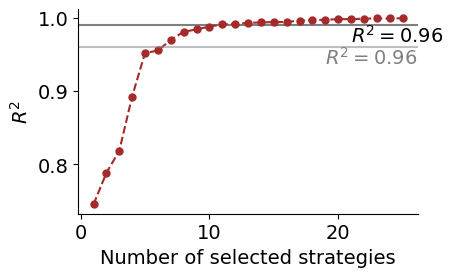

In [35]:
fig, ax = plt.subplots(1, figsize=(4.5, 3))

plt.plot(range(1, max_n_features_to_select + 1), r_squared_values, '--o', color='brown', markersize=5)

plt.axhline(.96, label="$R^2=.96$", color="grey", alpha=0.5)
plt.axhline(.99, label="$R^2=.99$", color="black", zorder=-1, alpha=0.5)

plt.xlabel("Number of selected strategies")
plt.ylabel("$R^2$")

plt.tight_layout()

ax.spines[['right', 'top']].set_visible(False)

ax.text(21, 0.967, "$R^2=0.96$", color="black")

ax.text(19, 0.937, "$R^2=0.96$", color="grey");



In [36]:
def write_linear_model_to_file(file_prefix, number_of_strategies=None, strategies=None):
    model = LinearRegression()
    Y =  scores["Scores"]
    
    if strategies is None:
        rfe = RFE(model, n_features_to_select=number_of_strategies)
        X = scores[second_tournament_strategies]
        fit = rfe.fit(X, Y)
        strategies = [name 
              for i, name in enumerate(second_tournament_strategies)
              if fit.support_[i]]      
        
    X = scores[strategies]
    model.fit(X, Y)
    

    coefficients = model.coef_
    intercept = model.intercept_
    
    F_values, p_values = f_regression(X, Y)
        
    
    with open("../paper/assets/" + file_prefix + "_{}_model.tex".format(number_of_strategies).replace("None_", "",), "w") as f:
        f.write(pd.DataFrame({"Strategies": strategies + ["Intercept"], 
                              "Coefficients": list(coefficients) + [intercept], 
                              "$p$-value": list(p_values) + ["NA"],
                              "$F$-value": list(F_values) + ["NA"]}
                            )[["Strategies", "Coefficients", "$p$-value", "$F$-value"]].round(5).to_latex(index=False).replace("\\$", "$"))
    
    if number_of_strategies is not None:
        r_squared = r2_score(scores["Scores"], 
                             scores["Predicted scores {} strategies".format(number_of_strategies)])
    else:
        r_squared = r2_score(scores["Scores"], 
                             model.predict(X))
    with open("../paper/assets/" + file_prefix + "_{}_r_squared.tex".format(number_of_strategies).replace("None_", "",), "w") as f:
        f.write("{:.3f}".format(r_squared))
        
    with open("data/linear_regression/" + file_prefix + "_{}_strategies.csv".format(number_of_strategies).replace("None_", "",), "w") as f:
        for player, weight in zip(strategies, coefficients):
            f.write("{},{}\n".format(player, weight))
        
    return model, r_squared

In [37]:
# for number in [5, 8, 25]:
#     write_linear_model_to_file(file_prefix="original_tournament_predictive", 
#                                number_of_strategies=number)

In [38]:
representative_strategies = ['k60r', 'k91r', 'k40r', 'k76r', 'k67r']
coefficients = [0.202, 0.198, 0.110, 0.072, 0.086]
intercept= 120 / 151
scores["Representative scores"] = intercept + sum(
                                            scores[strategy] * coefficient 
                                            for strategy, coefficient in zip(representative_strategies, 
                                                                             coefficients))


    
with open("../paper/assets/original_tournament_representative_model.tex", "w") as f:
    f.write(pd.DataFrame({"Strategies": representative_strategies + ["Intercept"], 
                          "Coefficients": list(coefficients) + [intercept]}
                        )[["Strategies", "Coefficients"]].round(3).to_latex(index=False))
    
    
representative_r_squared = r2_score(scores["Scores"], scores["Representative scores"])
print(representative_r_squared)
with open("../paper/assets/original_tournament_representative_r_squared.tex", "w") as f:
    f.write("{:.4f}".format(representative_r_squared))
    
with open("data/linear_regression/original_tournament_representative_strategies.csv", "w") as f:
    for player, weight in zip(representative_strategies, coefficients):
        f.write("{},{}\n".format(player, weight))

0.9517201700900602


In [39]:
linear_model_with_original_5, linear_model_with_original_5_r_squared  = write_linear_model_to_file(
                           file_prefix="original_tournament_predictive_with_axelrod_5", 
                           strategies=representative_strategies)

In [40]:
linear_model_with_original_5, linear_model_with_original_5_r_squared

(LinearRegression(), 0.9568929023459379)

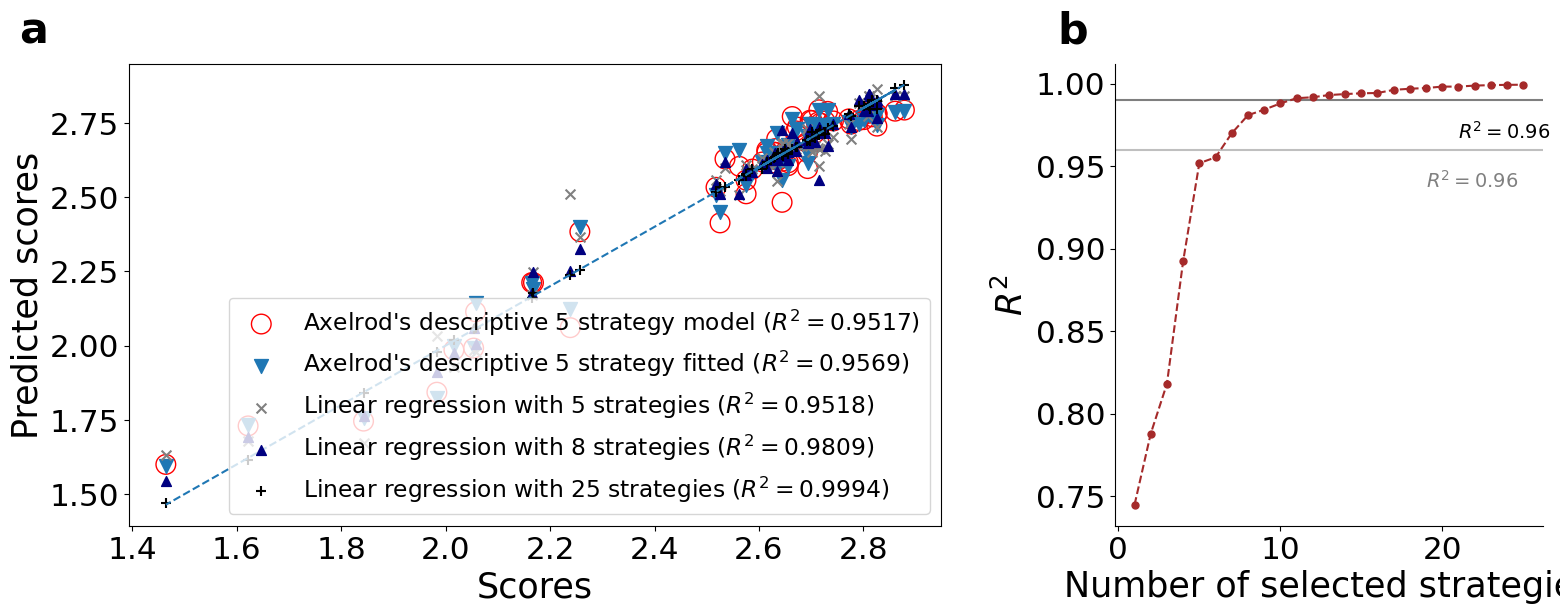

In [41]:
# Supplementary Figure 2: linear-model panels combined into a single PDF.
fig = plt.figure(figsize=(16, 6))
subfig_a, subfig_b = fig.subfigures(1, 2, width_ratios=[1.9, 1])

# Panel a: representative strategies and predicted scores
ax_a = subfig_a.subplots()
ax_a.plot(scores["Scores"], scores["Scores"], linestyle="dashed")
ax_a.scatter(scores["Scores"], scores["Representative scores"],
             label="Axelrod's descriptive 5 strategy model ($R^2={:.4f}$)".format(representative_r_squared),
             s=200, facecolors='none', edgecolors='r')
ax_a.scatter(scores["Scores"], linear_model_with_original_5.predict(scores[representative_strategies]),
             label="Axelrod's descriptive 5 strategy fitted ($R^2={:.4f}$)".format(linear_model_with_original_5_r_squared),
             s=100, marker="v")
ax_a.scatter(scores["Scores"], scores["Predicted scores 5 strategies"],
             label="Linear regression with 5 strategies ($R^2={:.4f}$)".format(r_squared_values[4]),
             s=50, marker="x", color="grey")
ax_a.scatter(scores["Scores"], scores["Predicted scores 8 strategies"],
             label="Linear regression with 8 strategies ($R^2={:.4f}$)".format(r_squared_values[7]),
             s=50, marker="^", color="navy")
ax_a.scatter(scores["Scores"], scores["Predicted scores 25 strategies"],
             label="Linear regression with 25 strategies ($R^2={:.4f}$)".format(r_squared_values[24]),
             s=50, marker="+", color="black")
ax_a.tick_params(labelsize=16 * FONT_SCALE)
ax_a.legend(fontsize=12 * FONT_SCALE)
ax_a.set_xlabel("Scores", fontsize=18 * FONT_SCALE)
ax_a.set_ylabel("Predicted scores", fontsize=18 * FONT_SCALE)

# Panel b: R^2 as a function of the number of selected strategies
ax_b = subfig_b.subplots()
ax_b.plot(range(1, max_n_features_to_select + 1), r_squared_values, '--o', color='brown', markersize=5)
ax_b.axhline(.96, color="grey", alpha=0.5)
ax_b.axhline(.99, color="black", zorder=-1, alpha=0.5)
ax_b.set_xlabel("Number of selected strategies", fontsize=18 * FONT_SCALE)
ax_b.set_ylabel("$R^2$", fontsize=18 * FONT_SCALE)
ax_b.tick_params(labelsize=16 * FONT_SCALE)
ax_b.spines[['right', 'top']].set_visible(False)
ax_b.text(21, 0.967, "$R^2=0.96$", color="black")
ax_b.text(19, 0.937, "$R^2=0.96$", color="grey")

# Panel labels
subfig_a.text(0.02, 0.97, "a", fontsize=22 * FONT_SCALE, fontweight="bold", va="top", ha="left")
subfig_b.text(0.02, 0.97, "b", fontsize=22 * FONT_SCALE, fontweight="bold", va="top", ha="left")

fig.savefig("../paper/assets/Figure_linear_regression_results.pdf",
            transparent=True, bbox_inches="tight")

# What was the tournament "like"

Let us take a look at summary statistics and cooperation rates.

In [42]:
with open("../paper/assets/original_tournament_overall_cooperation_rate.tex", "w") as f:
    f.write("{:.03f}".format(np.mean(original_tournament_cooperation_rates)))
np.mean(original_tournament_cooperation_rates)

0.750372377314919

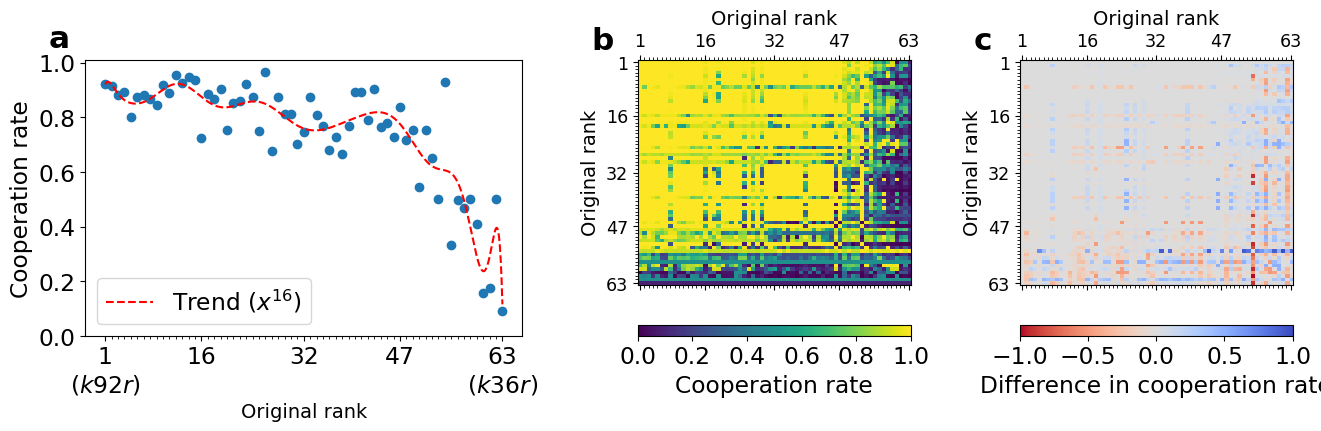

In [43]:
fig, axes = plt.subplot_mosaic(
    """ABC""",
    figsize=(13, 4.2),
    gridspec_kw={"hspace": 0.3, "wspace": 0.1, "width_ratios": [.8, 0.5, 0.5]},
    constrained_layout=True,  # helps alignment
)

# --- Panel A: scatter + trend ---
axes["A"].scatter(
    ranking_df["Reproduced Rank"], ranking_df["Mean Cooperation Rate"],
)

degree = 16
z = np.polyfit(ranking_df["Reproduced Rank"], ranking_df["Mean Cooperation Rate"], degree)
p = np.poly1d(z)
x = np.linspace(1, ranking_df["Reproduced Rank"].max(), 1000)
axes["A"].plot(x, p(x), "r--", label=f"Trend ($x^{{{degree}}}$)")

axes["A"].set_ylabel("Cooperation rate", fontsize=12 * FONT_SCALE)

labels = [f"{i}" for i in [1, 16, 32, 47, 63]]
labels[0] = "1\n" + r"$(\mathit{k92r})$"
labels[-1] = "63\n" + r"$(\mathit{k36r})$"

axes["A"].set_xticks([1, 16, 32, 47, 63])
axes["A"].set_xticks(range(1, len(scores.index) + 1), minor=True)
axes["A"].set_xticklabels(labels, fontsize=12 * FONT_SCALE)
axes["A"].set_yticks(np.arange(0, 1.2, 0.2))
axes["A"].set_yticklabels(np.arange(0, 1.2, 0.2).round(2), fontsize=12 * FONT_SCALE)
axes["A"].legend(fontsize=12 * FONT_SCALE)
axes["A"].set_xlabel("Original rank")

# --- Panel B: cooperation ---
matrix = cooperation_rates[scores.index].reindex(scores.index)
player_names = scores.index

im = axes["B"].matshow(matrix, cmap="viridis", vmin=0, vmax=1)
axes["B"].set_aspect("auto")

# ticks
axes["B"].set_xticks([0, 15, 31, 46, 62])
axes["B"].set_yticks([0, 15, 31, 46, 62])
axes["B"].set_xticks(range(0, len(scores.index)), minor=True)
axes["B"].set_yticks(range(0, len(scores.index)), minor=True)

axes["B"].set_xticklabels([f"{i}" for i in [1, 16, 32, 47, 63]], fontsize=9 * FONT_SCALE)
axes["B"].set_yticklabels([f"{i}" for i in [1, 16, 32, 47, 63]], fontsize=9 * FONT_SCALE)

# axis labels
axes["B"].set_ylabel("Original rank", fontsize=10 * FONT_SCALE)
axes["B"].set_title("Original rank", fontsize=10 * FONT_SCALE)

# put colorbar at the bottom
divider = make_axes_locatable(axes["B"])
cax = divider.append_axes("bottom", size="5%", pad=0.4)  # pad a bit for space
cb = fig.colorbar(im, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=12 * FONT_SCALE)
cb.set_ticks([i for i in np.arange(0, 1.2, 0.2)])
cb.set_label("Cooperation rate", fontsize=12 * FONT_SCALE)


# --- Panel B: symmetry ---
heatmap = matrix.values
symmetric = heatmap - heatmap.T

im = axes["C"].matshow(symmetric, cmap="coolwarm_r", vmin=-1, vmax=1)
axes["C"].set_aspect("auto")

# ticks
axes["C"].set_xticks([0, 15, 31, 46, 62])
axes["C"].set_yticks([0, 15, 31, 46, 62])
axes["C"].set_xticks(range(0, len(scores.index)), minor=True)
axes["C"].set_yticks(range(0, len(scores.index)), minor=True)

axes["C"].set_xticklabels([f"{i}" for i in [1, 16, 32, 47, 63]], fontsize=9 * FONT_SCALE)
axes["C"].set_yticklabels([f"{i}" for i in [1, 16, 32, 47, 63]], fontsize=9 * FONT_SCALE)

# axis labels
axes["C"].set_ylabel("Original rank", fontsize=10 * FONT_SCALE)
axes["C"].set_title("Original rank", fontsize=10 * FONT_SCALE)

# put colorbar at the bottom
divider = make_axes_locatable(axes["C"])
cax = divider.append_axes("bottom", size="5%", pad=0.4)  # pad a bit for space
cb = fig.colorbar(im, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=12 * FONT_SCALE)
cb.set_ticks([-1, -0.5, 0, 0.5, 1])
cb.set_label("Difference in cooperation rate", fontsize=12 * FONT_SCALE)


axes["A"].text(-.085, 1.13, f"a", transform=axes["A"].transAxes,
               fontsize=16 * FONT_SCALE, fontweight='bold', va='top', ha='left')

axes["B"].text(-.17, 1.15, f"b", transform=axes["B"].transAxes,
               fontsize=16 * FONT_SCALE, fontweight='bold', va='top', ha='left')

axes["C"].text(-.17, 1.15, f"c", transform=axes["C"].transAxes,
               fontsize=16 * FONT_SCALE, fontweight='bold', va='top', ha='left')

plt.savefig("../paper/Figure_3.pdf", bbox_inches='tight');

### Tables

In [44]:
def break_header(s):
    s = s.replace(" / ", r"\\")
    return r"\makecell[c]{" + s.replace("\n", r"\\") + "}"

In [45]:
ranking_df = scores[["Author", "Scores", "Reproduced Rank", "Original Rank"]].round(4)
ranking_df = ranking_df.join(original_cooperation_rates[["Mean Cooperation Rate"]])
ranking_df = ranking_df.join(proportions)
ranking_df.head()

,Author,Scores,Reproduced Rank,Original Rank,Mean Cooperation Rate,proportion
k92r,Anatol Rapoport,2.8785,1,1,0.921831,0.63064
k61r,Danny C Champion,2.7907,12,2,0.954240,NaN
k42r,Otto Borufsen,2.8607,2,3,0.916128,0.31488
k49r,Rob Cave,2.8260,4,4,0.892220,NaN
k44r,William Adams,2.8260,3,5,0.881894,0.00384


In [46]:
ranking_df = ranking_df.rename(columns={'Scores': 'Average Score'})
ranking_df = ranking_df.rename(columns={"Mean Cooperation Rate": 'Average / Cooperation Rate'})
ranking_df = ranking_df.rename(columns={"proportion": 'Win / proportion'})
ranking_df = ranking_df.fillna(0)

In [47]:
with open("../paper/assets/original_tournament_rankings.tex", "w") as f:
    f.write(ranking_df.rename(columns=break_header).head(15).to_latex(float_format="%.4f").replace("rrrr", "cccc"))

In [48]:
ranking_df[ranking_df['Average / Cooperation Rate'] < 0.5]

,Author,Average Score,Reproduced Rank,Original Rank,Average / Cooperation Rate,Win / proportion
k48r,George Hufford,2.2569,53,53,0.499545,0.0
k77r,Scott Feld,2.1681,55,55,0.332062,0.0
k89r,Gene Snodgrass,2.1647,56,56,0.497671,0.0
k54r,William H Robertson,2.0572,57,58,0.466780,0.0
k33r,Harold Rabbie,2.0157,59,59,0.410634,0.0
k71r,James E Hall,1.9831,60,60,0.157546,0.0
k74r,Edward Friedland,1.8426,61,61,0.173823,0.0
krandomc,0,1.6215,62,62,0.499971,0.0
k36r,Roger Hotz,1.4640,63,63,0.091591,0.0
